# Proportion-based hybrid nearest neighbors even during all cross-validations, plot generation

## Imports

In [6]:
# import cuml
# cuml.accel.install()
# %load_ext cuml.accel
%load_ext autoreload
%load_ext rpy2.ipython
%autoreload 2
%reload_ext autoreload
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt
import pandas as pd
from pandas.io.parsers import read_csv
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from hybrids import max_pareto_front, hyb_KNeighborsClassifier
import pylab
# Swap KNeighborsClassifier if no gpu
from cuml.neighbors import KNeighborsClassifier
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import auc
import matplotlib.pyplot as plt
%matplotlib inline
pylab.rcParams['figure.figsize'] = (5, 5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## Data reading

In [7]:
blackbox = 'rf'  # Random forest
# blackbox = 'ab'  # AdaBoosted decision trees
# blackbox = 'xg'  # XGboost (gbtree)

In [8]:
path = './datasets/census/'; name = 'census'

# path = './datasets/coupon/'; name = 'coupon'

# path = './datasets/stop&frisk/'; name = 'stop-and-frisk'

In [9]:
normalize = True

# read data
Xtrain = read_csv(path + 'train.csv',header = 0, sep = ',')
Xtest = read_csv(path + 'test.csv',header = 0, sep = ',')
bbm = read_csv(path + blackbox + '_ybtrain.csv',header = 0,sep = ',')
Ybtrain = np.array(bbm['Yb'])
bbm = read_csv(path + blackbox + '_ybtest.csv',header = 0,sep = ',')
Ybtest = np.array(bbm['Yb'])

ntrain = Xtrain.shape[0]
df = pd.concat([Xtrain, Xtest])
# Seperate Y (answers) from dataframe
Y = np.array(df['Y'])
df.drop(['Y'], axis = 1, inplace = True) 
numericals = [col for col in Xtrain.columns if Xtrain[col].dtype in [int, float] and (~Xtrain[col].isin([0, 1])).any()]

if normalize:
    # Normalize data
    df = df.astype({col: float for col in numericals})
    mean = Xtrain.loc[:, numericals].mean(axis=0)
    std = Xtrain.loc[:, numericals].std(axis=0) + 1e-8
    df.loc[:, numericals] = (df.loc[:, numericals] - mean) / std


ntrain = Xtrain.shape[0]
Ytrain = Y[:ntrain]
Ytest = Y[ntrain:]
Xtrain = df[:ntrain].to_numpy()
Xtest = df[ntrain:].to_numpy()
Xtrain = np.hstack((Xtrain, Ybtrain[:, np.newaxis]))
Xtest = np.hstack((Xtest, Ybtest[:, np.newaxis]))


## Calculate probabilities for probabilistic KNN

Using greedy search to try finding best subset for all amount of features

In [ ]:
feature_len = Xtrain.shape[1]
# False for backward feature selection
forward = True
# maximum k for k selection via cross-validation
k_le = 20

# perform sequential feature search (greedy search)
feature_len = Xtrain.shape[1]
results = []
for offload_thrs in np.append(np.linspace(0, 0.5, 5, True), 0.6):
    print(f"theta(offload threshold): {offload_thrs}")
    hybknn = hyb_KNeighborsClassifier(n_neighbors=11, n_jobs=1, defer_threshold=offload_thrs, gpu=True)
    SFS1 = SFS(
            hybknn,
            k_features=(2, feature_len),
            forward=forward,
            # Floating selection takes more than 24 hours
            floating=False,
            n_jobs=1,
            verbose=2,
            cv=2,
            fixed_features=(Xtrain.shape[1] - 1,)
        )

    SFS1.fit(Xtrain, Ytrain)

    param_grid = {'n_neighbors': range(5, k_le + 1)}
    grid = GridSearchCV(hyb_KNeighborsClassifier(n_jobs=1, defer_threshold=offload_thrs, gpu=True), param_grid, n_jobs=1, refit=True, verbose=0, error_score="raise")

    def fit_one(i):
        print(f"Features: {i}")
        feature_subset = np.array(SFS1.subsets_[i]['feature_idx'])
        
        grid.fit(Xtrain[:, feature_subset], Ytrain)
        hybknn = grid.best_estimator_
        res =  hybknn.score_detail(Xtest[:, feature_subset], Ytest)
        res.update({
            'features_used': i,
            'k-nearest': grid.best_params_["n_neighbors"]
            })
        return res

    for i in range(2, feature_len+1):
        results.append(fit_one(i))

results_df = pd.DataFrame(results)
# results_df.to_csv(path + f"{name}_{blackbox}_hybkNN_proc1_le{k_le}{"fwgreedy" if forward else "bcgreedy"}_results.csv", index=False)

theta(offload threshold): 0.0


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 108 out of 108 | elapsed:    1.3s finished

[2026-06-16 20:31:40] Features: 2/109 -- score: 0.8085746948516435[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 107 out of 107 | elapsed:    1.9s finished

[2026-06-16 20:31:42] Features: 3/109 -- score: 0.8289364669961685[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 106 out of 106 | elapsed:    1.9s finished

[2026-06-16 20:31:44] Features: 4/109 -- score: 0.8295200126253195[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 105 out of 105 | elapsed:    1.3s finished

[2026-06-16 20:31:45] Features: 5/109 -- score: 0.8319462459595129[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 104 out of 104 | elapsed:    1.3s finished

[2026-06-16 20:31:46] Features: 6/109 -- score: 0.8353859154646883[Parallel(

Features: 2
Features: 3
Features: 4
Features: 5
Features: 6
Features: 7
Features: 8
Features: 9
Features: 10
Features: 11
Features: 12
Features: 13
Features: 14
Features: 15
Features: 16
Features: 17
Features: 18
Features: 19
Features: 20
Features: 21
Features: 22
Features: 23
Features: 24
Features: 25
Features: 26
Features: 27
Features: 28
Features: 29
Features: 30
Features: 31
Features: 32
Features: 33
Features: 34
Features: 35
Features: 36
Features: 37
Features: 38
Features: 39
Features: 40
Features: 41
Features: 42
Features: 43
Features: 44
Features: 45
Features: 46
Features: 47
Features: 48
Features: 49
Features: 50
Features: 51
Features: 52
Features: 53
Features: 54
Features: 55
Features: 56
Features: 57
Features: 58
Features: 59
Features: 60
Features: 61
Features: 62
Features: 63
Features: 64
Features: 65
Features: 66
Features: 67
Features: 68
Features: 69
Features: 70
Features: 71
Features: 72
Features: 73
Features: 74
Features: 75
Features: 76
Features: 77
Features: 78
Feature

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 108 out of 108 | elapsed:    1.2s finished

[2026-06-16 20:36:03] Features: 2/109 -- score: 0.8084211208796614[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 107 out of 107 | elapsed:    1.8s finished

[2026-06-16 20:36:05] Features: 3/109 -- score: 0.8340046778272316[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 106 out of 106 | elapsed:    1.7s finished

[2026-06-16 20:36:06] Features: 4/109 -- score: 0.8580204054499245[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 105 out of 105 | elapsed:    1.3s finished

[2026-06-16 20:36:07] Features: 5/109 -- score: 0.8357858951971722[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 104 out of 104 | elapsed:    1.3s finished

[2026-06-16 20:36:09] Features: 6/109 -- score: 0.8363386849083366[Parallel(

Features: 2
Features: 3
Features: 4
Features: 5
Features: 6
Features: 7
Features: 8
Features: 9
Features: 10
Features: 11
Features: 12
Features: 13
Features: 14
Features: 15
Features: 16
Features: 17
Features: 18
Features: 19
Features: 20
Features: 21
Features: 22
Features: 23
Features: 24
Features: 25
Features: 26
Features: 27
Features: 28
Features: 29
Features: 30
Features: 31
Features: 32
Features: 33
Features: 34
Features: 35
Features: 36
Features: 37
Features: 38
Features: 39
Features: 40
Features: 41
Features: 42
Features: 43
Features: 44
Features: 45
Features: 46
Features: 47
Features: 48
Features: 49
Features: 50
Features: 51
Features: 52
Features: 53
Features: 54
Features: 55
Features: 56
Features: 57
Features: 58
Features: 59
Features: 60
Features: 61
Features: 62
Features: 63
Features: 64
Features: 65
Features: 66
Features: 67
Features: 68
Features: 69
Features: 70
Features: 71
Features: 72
Features: 73
Features: 74
Features: 75
Features: 76
Features: 77
Features: 78
Feature

...

Features: 2
Features: 3
Features: 4
Features: 5
Features: 6
Features: 7
Features: 8
Features: 9
Features: 10
Features: 11
Features: 12
Features: 13
Features: 14
Features: 15
Features: 16
Features: 17
Features: 18
Features: 19
Features: 20
Features: 21
Features: 22
Features: 23
Features: 24
Features: 25
Features: 26
Features: 27
Features: 28
Features: 29
Features: 30
Features: 31
Features: 32
Features: 33
Features: 34
Features: 35
Features: 36
Features: 37
Features: 38
Features: 39
Features: 40
Features: 41
Features: 42
Features: 43
Features: 44
Features: 45
Features: 46
Features: 47
Features: 48
Features: 49
Features: 50
Features: 51
Features: 52
Features: 53
Features: 54
Features: 55
Features: 56
Features: 57
Features: 58
Features: 59
Features: 60
Features: 61
Features: 62
Features: 63
Features: 64
Features: 65
Features: 66
Features: 67
Features: 68
Features: 69
Features: 70
Features: 71
Features: 72
Features: 73
Features: 74
Features: 75
Features: 76
Features: 77
Features: 78
Feature

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 108 out of 108 | elapsed:    1.3s finished

[2026-06-16 20:49:07] Features: 2/109 -- score: 0.8493290026042928[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 107 out of 107 | elapsed:    1.4s finished

[2026-06-16 20:49:09] Features: 3/109 -- score: 0.8530144232880552[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 106 out of 106 | elapsed:    1.6s finished

[2026-06-16 20:49:10] Features: 4/109 -- score: 0.8536593543641637[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 105 out of 105 | elapsed:    1.4s finished

[2026-06-16 20:49:12] Features: 5/109 -- score: 0.8550721137993111[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 104 out of 104 | elapsed:    1.4s finished

[2026-06-16 20:49:13] Features: 6/109 -- score: 0.8555634973130828[Parallel(

Features: 2
Features: 3
Features: 4
Features: 5
Features: 6
Features: 7
Features: 8
Features: 9
Features: 10
Features: 11
Features: 12
Features: 13
Features: 14
Features: 15
Features: 16
Features: 17
Features: 18
Features: 19
Features: 20
Features: 21
Features: 22
Features: 23
Features: 24
Features: 25
Features: 26
Features: 27
Features: 28
Features: 29
Features: 30
Features: 31
Features: 32
Features: 33
Features: 34
Features: 35
Features: 36
Features: 37
Features: 38
Features: 39
Features: 40
Features: 41
Features: 42
Features: 43
Features: 44
Features: 45
Features: 46
Features: 47
Features: 48
Features: 49
Features: 50
Features: 51
Features: 52
Features: 53
Features: 54
Features: 55
Features: 56
Features: 57
Features: 58
Features: 59
Features: 60
Features: 61
Features: 62
Features: 63
Features: 64
Features: 65
Features: 66
Features: 67
Features: 68
Features: 69
Features: 70
Features: 71
Features: 72
Features: 73
Features: 74
Features: 75
Features: 76
Features: 77
Features: 78
Feature

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 108 out of 108 | elapsed:    1.3s finished

[2026-06-16 20:53:44] Features: 2/109 -- score: 0.85488782918302[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 107 out of 107 | elapsed:    1.5s finished

[2026-06-16 20:53:45] Features: 3/109 -- score: 0.85488782918302[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 106 out of 106 | elapsed:    1.7s finished

[2026-06-16 20:53:47] Features: 4/109 -- score: 0.85488782918302[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 105 out of 105 | elapsed:    1.4s finished

[2026-06-16 20:53:48] Features: 5/109 -- score: 0.85488782918302[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 104 out of 104 | elapsed:    1.4s finished

[2026-06-16 20:53:50] Features: 6/109 -- score: 0.85488782918302[Parallel(n_jobs=1)]

Features: 2
Features: 3
Features: 4
Features: 5
Features: 6
Features: 7
Features: 8
Features: 9
Features: 10
Features: 11
Features: 12
Features: 13
Features: 14
Features: 15
Features: 16
Features: 17
Features: 18
Features: 19
Features: 20
Features: 21
Features: 22
Features: 23
Features: 24
Features: 25
Features: 26
Features: 27
Features: 28
Features: 29
Features: 30
Features: 31
Features: 32
Features: 33
Features: 34
Features: 35
Features: 36
Features: 37
Features: 38
Features: 39
Features: 40
Features: 41
Features: 42
Features: 43
Features: 44
Features: 45
Features: 46
Features: 47
Features: 48
Features: 49
Features: 50
Features: 51
Features: 52
Features: 53
Features: 54
Features: 55
Features: 56
Features: 57
Features: 58
Features: 59
Features: 60
Features: 61
Features: 62
Features: 63
Features: 64
Features: 65
Features: 66
Features: 67
Features: 68
Features: 69
Features: 70
Features: 71
Features: 72
Features: 73
Features: 74
Features: 75
Features: 76
Features: 77
Features: 78
Feature

## Plot predictions using minimized results

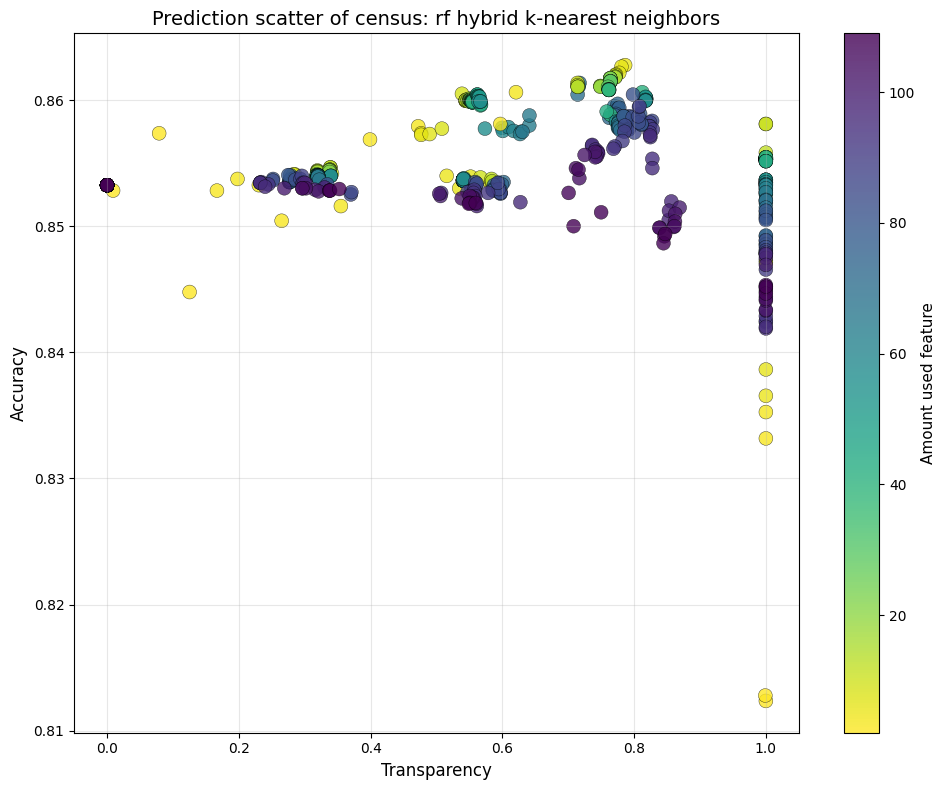

In [11]:
# Create the plot
plt.figure(figsize=(10, 8))

transparency_vals = [result['transparency'] for result in results]
accuracy_vals = [result['accuracy'] for result in results]
features_vals = [result['features_used'] for result in results]

scatter = plt.scatter(
    transparency_vals,
    accuracy_vals,
    c=features_vals,
    cmap='viridis_r',
    s=100,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.3,
 )

cbar = plt.colorbar(scatter)
cbar.set_label('Amount used feature', fontsize=11)

plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Prediction scatter of {name}: {blackbox} hybrid k-nearest neighbors', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f"{name}_{blackbox}_hybkNN_proc1_le{k_le}{"fwgreedy" if forward else "bcgreedy"}_scatter.svg")
plt.show()

#### Pareto front with unlimited features

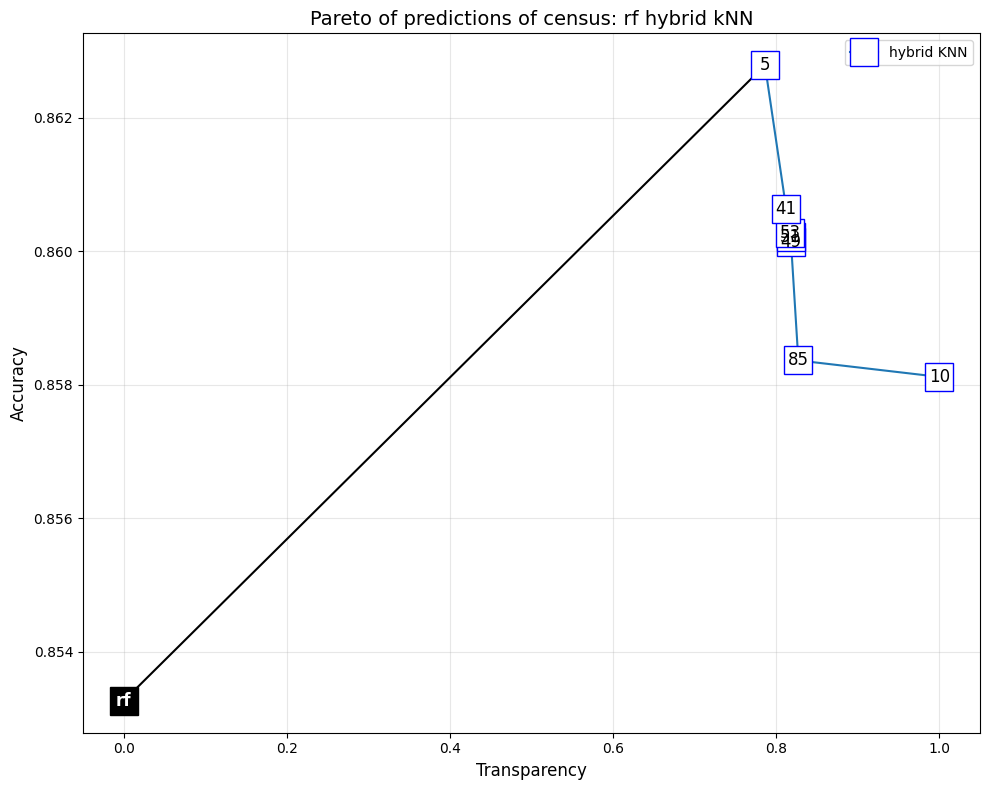

In [12]:
maxpf_df = max_pareto_front(results_df, "transparency", "accuracy")
yb_accuracy = (Ybtest == Ytest).mean()
# Create the plot
plt.figure(figsize=(10, 8))


axes = plt.gca()
plt.plot([0, maxpf_df.iloc[-1]["transparency"]], [yb_accuracy, maxpf_df.iloc[-1]["accuracy"]], color="black")
axes = maxpf_df.plot(x="transparency", y="accuracy", ax=axes, marker='s', markersize=20, markerfacecolor='white', markeredgecolor='blue', label="hybrid KNN")
plt.plot(0, yb_accuracy, 's', markersize=20, markerfacecolor='black', markeredgecolor='black')
for i, row in maxpf_df.iterrows():
    plt.text(row["transparency"], row["accuracy"], int(row["features_used"]), 
             ha='center', 
             va='center', 
             fontsize=12, 
             color='black', 
             )
plt.text(0, yb_accuracy, blackbox,
         ha='center', 
         va='center', 
         fontsize=12, 
         fontweight="bold",
         color="white")
plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Pareto of predictions of {name}: {blackbox} hybrid kNN', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hybkNN_proc1_le{k_le}{"fwgreedy" if forward else "bcgreedy"}_pareto.svg')
plt.show()

#### Pareto front with dataframe filtered by amount of features used

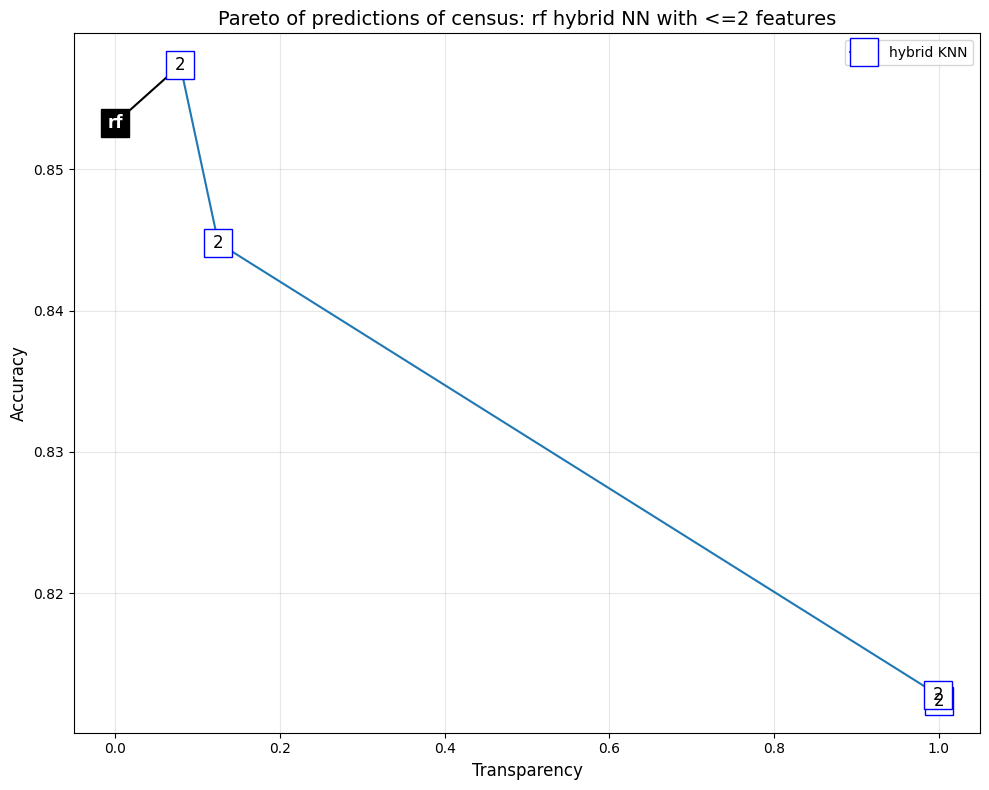

In [13]:
le_feature = 2
maxpf_df = max_pareto_front(results_df[results_df["features_used"] <= le_feature], "transparency", "accuracy")
yb_accuracy = (Ybtest == Ytest).mean()
# Create the plot
plt.figure(figsize=(10, 8))


axes = plt.gca()
plt.plot([0, maxpf_df.iloc[-1]["transparency"]], [yb_accuracy, maxpf_df.iloc[-1]["accuracy"]], color="black")
axes = maxpf_df.plot(x="transparency", y="accuracy", ax=axes, marker='s', markersize=20, markerfacecolor='white', markeredgecolor='blue', label="hybrid KNN")
plt.plot(0, yb_accuracy, 's', markersize=20, markerfacecolor='black', markeredgecolor='black')
for i, row in maxpf_df.iterrows():
    plt.text(row["transparency"], row["accuracy"], int(row["features_used"]), 
             ha='center', 
             va='center', 
             fontsize=12, 
             color='black', 
             )
plt.text(0, yb_accuracy, blackbox,
         ha='center', 
         va='center', 
         fontsize=12, 
         fontweight="bold",
         color="white")
plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Pareto of predictions of {name}: {blackbox} hybrid NN with <={le_feature} features', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hybkNN_proc1_le{k_le}{"fwgreedy" if forward else "bcgreedy"}_pareto_featurefilteredby{le_feature}.png')
plt.show()

## Colerful AUTAC (area under the accuracy-transparency trade-off curve) bar

AUTAC with feature$\leq2$: 0.8320637940419282
AUTAC with feature$\leq10$: 0.8622860993060646
AUTAC with feature$\leq20$: 0.8622860993060646
AUTAC with feature$\leq30$: 0.8622860993060646
AUTAC with feature$\leq40$: 0.8622860993060646
AUTAC with feature$\leq50$: 0.8620784454770962
AUTAC with feature$\leq60$: 0.8620786152429575
AUTAC with feature$\leq70$: 0.8620786152429575
AUTAC with feature$\leq80$: 0.8620786152429575
AUTAC with feature$\leq90$: 0.86192590896443
AUTAC with feature$\leq100$: 0.86192590896443
AUTAC with No restriction: 0.86192590896443


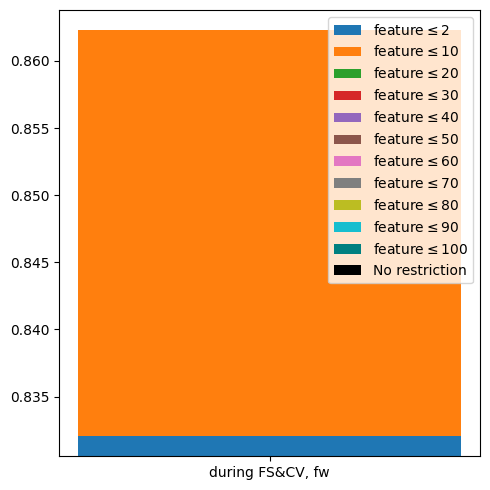

In [14]:
def get_autacs(th):
    pareto_df = max_pareto_front(
        (results_df[results_df["features_used"] <= th]) if th != None else results_df, "transparency", "accuracy"
    ).sort_values("transparency", ascending=False, ignore_index=True)
    pareto_df.loc[len(pareto_df)] = {
        "offload_thrs": 0,
        "transparency": 0,
        "accuracy": pareto_df["accuracy"].iloc[-1],
        "features_used": pareto_df["features_used"].iloc[-1],
    }
    return auc(pareto_df["transparency"], pareto_df["accuracy"])

ax = plt.gca()


feature_filter_list = [2] + list(range(10, 101, 10)) + [None]
autacs = [get_autacs(th) for th in feature_filter_list]
labels = [f"feature$\\leq{th}$" if th is not None else "No restriction" for th in feature_filter_list]
colors = [f"C{i}" for i in range(10)] + ["teal", "black"]

au_max = max(autacs)
au_min = min(autacs)
margin = (au_max - au_min) * 0.05
range_min = au_min - margin
range_max = au_max + margin

for idx, autac in enumerate(autacs):
    print(f"AUTAC with {labels[idx]}:",autac)
    ax.bar(
        [f"during FS&CV, {"fw" if forward else "bw"}"], 
        autac, label=labels[idx], 
        color=colors[idx], 
        zorder=-idx
        )
ax.set_ylim(range_min, range_max)
plt.tight_layout()
plt.legend()
plt.show()